In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import jax.numpy as jnp
from jax import jit, vmap, grad

from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
import functions as f

In [ ]:
device_name = "cpu"

We aim at minimizing $$\mathcal{F}_P(Q) = \mathcal{L}(Q) + D_{KL}(Q||Q_0)$$ where $Q_0 = \mathcal{N}(0,I_d)$ and $P$ is the minimizer and has a positive density $$p(x) \propto q_0(x) \exp(-\mathcal{L}'(P)(x)).$$
To do this we run the stochastic process, for $k=1,...,T$,
$$X[k+1] = X[k] - \eta \nabla 
V(X[k]) + \sqrt{2 \eta} Z[k]$$
where 
- X[k] is a set of particules at recursion $k$ ($n$ particules in $\mathbb{R}^d$) (shape $(n,d)$)
- $n$ is the number of particules and $d$ the dimension
- $Z[1],...,Z[T]$ are iid gaussian noises (shape $(n,d)$)
- $\nabla V (X[k]) = \nabla_W \mathcal{L}(\hat{Q}[k])(X[k]) - \nabla \log q_0(X[k])$ where $\hat{Q}[k] = \frac1n \sum_{j=1}^n \delta_{X^j[k]}$.



<!-- In what follows we controll visually that the distribution converges to $\mathcal{N}(0,2 I_d)$. -->

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = f(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [2]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import matplotlib.pyplot as plt
#from kgd_code import mfld
from modules.mfld import MeanFieldLangevinDynamics
from modules.kgd_functions import F_P, GradientKernel, KernelGradientDiscrepancy
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util
import matplotlib

In [3]:
device_name = "cpu"

2 layer neural network :

In [4]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

Generation of the data

In [5]:

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)

$k$, $q_0$ and $\mathcal{L}$

In [ ]:
def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)


k = jit(lambda x, y: k_imq(x, y, 1, 0.5))

def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/2) 

def grad_log_q0(X):
    return - X

def L(X, unravel_fn, Z, Y, gamma=100):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

gamma = 300
L_ = lambda X: L(X, unravel_fn, Z_train, Y_train, gamma)

k = jit(k)
q_0 = jit(q_0)
L_ = jit(L_)  
 
MFLD = MeanFieldLangevinDynamics(grad_log_q0,L_)    

to do : plot the parameters

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Paramètres
T = 1000
n = 100
nb_runs = 50   # number of runs for statistics
d = len(flat_params)

num_stepsizes = 35
Eta = jnp.logspace(-5, -2.7, num=num_stepsizes)


F_P = F_P(q_0, L_)
k_pq = GradientKernel(MFLD.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

#array to stock the runs 
KGD_all   = jnp.zeros((nb_runs, len(Eta)))
F_P_all   = jnp.zeros((nb_runs, len(Eta)))
L_all     = jnp.zeros((nb_runs, len(Eta)))

for r in range(nb_runs):
    if r//10 == 0:
        print(f"Run {r+1}/{nb_runs}")

    all_particles_fin = jnp.zeros((len(Eta), n, d))

    for e, eta in enumerate(Eta):
        key = random.PRNGKey(r)
        key, subkey = random.split(key)
        X0 = random.normal(subkey, shape=(n, d))

        all_particles = MFLD.run_particles(eta, T, X0, key)
        all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

     # Evaulation of the metrics
    KGD_fin = jnp.zeros(len(Eta))
    F_P_fin = jnp.zeros(len(Eta))
    L_fin   = jnp.zeros(len(Eta))
    KGD_KDE_fin = jnp.zeros(len(Eta))

    for e in range(len(Eta)):
        X = all_particles_fin[e]
        KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
        F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X, num_samples=300))
        L_fin   = L_fin.at[e].set(L(X,unravel_fn, Z_test, Y_test, gamma))
        KGD_KDE_fin = KGD_KDE_fin.at[e].set(KGD.kde_KGD(X, num_samples=300))

    
    KGD_all = KGD_all.at[r].set(KGD_fin)
    F_P_all = F_P_all.at[r].set(F_P_fin)
    L_all   = L_all.at[r].set(L_fin)
    KGD_KDE_all = KGD_all.at[r].set(KGD_KDE_fin)

# quantiles
def summary_stats(arr):
    mean = arr.mean(axis=0)
    q10 = jnp.quantile(arr, 0.1, axis=0)
    q90 = jnp.quantile(arr, 0.9, axis=0)
    return mean, q10, q90

KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90       = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)



Run 1/50
Run 2/50
Run 3/50
Run 4/50
Run 5/50
Run 6/50
Run 7/50
Run 8/50
Run 9/50
Run 10/50
Run 11/50
Run 12/50
Run 13/50
Run 14/50
Run 15/50
Run 16/50
Run 17/50
Run 18/50
Run 19/50
Run 20/50
Run 21/50
Run 22/50
Run 23/50
Run 24/50
Run 25/50
Run 26/50
Run 27/50
Run 28/50
Run 29/50
Run 30/50
Run 31/50
Run 32/50
Run 33/50
Run 34/50
Run 35/50
Run 36/50
Run 37/50
Run 38/50
Run 39/50
Run 40/50
Run 41/50
Run 42/50
Run 43/50
Run 44/50
Run 45/50
Run 46/50
Run 47/50
Run 48/50
Run 49/50
Run 50/50


In [9]:
import csv

# Recalculer les bonnes statistiques
KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90 = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)

#Sauvegarder correctement
with open("/tmp/summary_stats.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Variable", "Mean", "Q10", "Q90"])
    writer.writerow(["KGD", KGD_mean, KGD_q10, KGD_q90])
    writer.writerow(["F_P", F_P_mean, F_P_q10, F_P_q90])
    writer.writerow(["L", L_mean, L_q10, L_q90])
    writer.writerow(["KGD_KDE", KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90])

In [4]:
import pandas as pd

df = pd.read_csv("/tmp/summary_stats.csv")

import numpy as np

def str_to_float_array(s):
    return np.fromstring(s.strip('[]'), sep=' ')

# Accès propre avec .iloc[0]
KGD_mean     = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Mean'].iloc[0])
KGD_q10      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q10'].iloc[0])
KGD_q90      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q90'].iloc[0])

# F_P
F_P_mean     = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Mean'].iloc[0])
F_P_q10      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q10'].iloc[0])
F_P_q90      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q90'].iloc[0])

# L
L_mean       = str_to_float_array(df.loc[df['Variable'] == 'L', 'Mean'].iloc[0])
L_q10        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q10'].iloc[0])
L_q90        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q90'].iloc[0])

# KGD_KDE
KGD_KDE_mean = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Mean'].iloc[0])
KGD_KDE_q10  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q10'].iloc[0])
KGD_KDE_q90  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q90'].iloc[0])

In [ ]:
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['ps.useafm'] = True
matplotlib.rcParams['pdf.use14corefonts'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

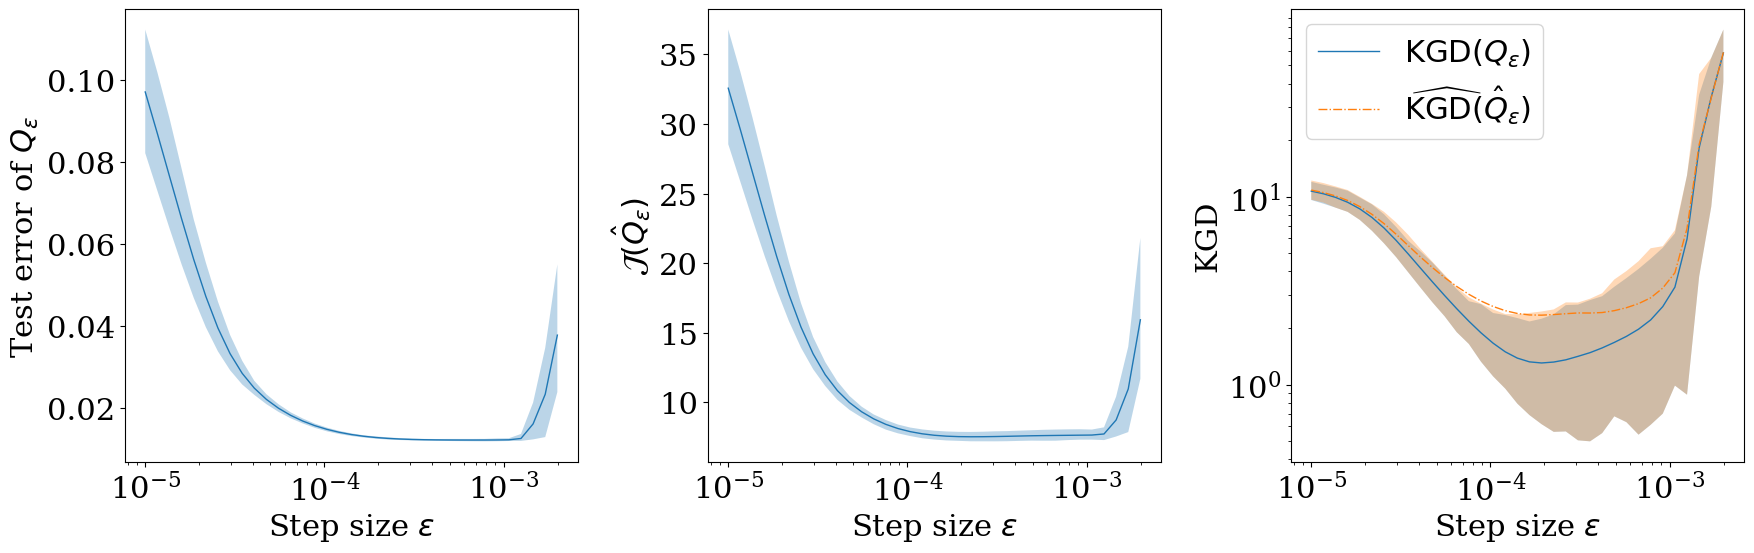

In [27]:
import seaborn as sns
colors = sns.color_palette("colorblind")
#plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Generalisation error (MSE)
axes[0].plot(Eta, (1/gamma) * L_mean, label="L (mean)")
axes[0].fill_between(Eta, (1/gamma) * L_q10, (1/gamma) * L_q90, alpha=0.3)
axes[0].set_xscale("log")
axes[0].set_xlabel(r'Step size $\epsilon$')
axes[0].set_ylabel(r'Test error of $Q_\epsilon$')
#axes[0].set_title("MSE Final vs. Eta")

# F_P
axes[1].plot(Eta, F_P_mean, label="F_P (mean)")
axes[1].fill_between(Eta, F_P_q10, F_P_q90, alpha=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel(r'Step size $\epsilon$')
axes[1].set_ylabel(r'$\mathcal{J}(\hat{Q}_\epsilon)$')
#axes[1].set_title(r"$\mathcal{F}_P$ Final vs. $\eta$")

# KGD
axes[2].plot(Eta, KGD_mean, label=r'$\mathrm{KGD}(Q_\epsilon)$')
axes[2].fill_between(Eta, KGD_q10, KGD_q90, alpha=0.3)
axes[2].plot(Eta, KGD_KDE_mean, linestyle='-.', label=r'$\widehat{\mathrm{KGD}}(\hat{Q}_\epsilon)$')
axes[2].fill_between(Eta, KGD_KDE_q10, KGD_KDE_q90, alpha=0.3)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r'Step size $\epsilon$')
axes[2].set_ylabel('KGD')
#axes[0].set_title(r"KGD Final vs. $\eta$")
axes[2].legend()

plt.tight_layout()
#plt.savefig("final_metrics_plot.pdf", bbox_inches='tight')

In [22]:
# Check if the best stepsize is the same for KGD and F_P
e_min_KGD = jnp.argmin(KGD_mean[:-1])
e_min_F_P = jnp.argmin(F_P_mean[:-1])
print(f"Best Eta for KGD: {Eta[e_min_KGD]:.4f}")
print(f"Best Eta for F_P: {Eta[e_min_F_P]:.4f}")


Best Eta for KGD: 0.0002
Best Eta for F_P: 0.0002


Plot of the predictions